### Load Data

In [69]:
#Clear memory
globals().clear()

# Read and aggregate all 2023 parquet files into memory
import os, glob
import pandas as pd
import numpy as np

# SOURCE_DIR already defined in an earlier cell; redefine here for safety if needed
SOURCE_DIR = r"C:\Users\Matt\Desktop\CS506\CS506_Project\1_LIB\nyiso\nyiso_parquet"

def find_parquets(src):
    pattern = os.path.join(src, '**', '*.parquet')
    return sorted(glob.glob(pattern, recursive=True))

def load_parquets(paths):
    dfs = []
    for p in paths:
        try:
            df = pd.read_parquet(p)
            df['_source_file'] = os.path.basename(p)
            dfs.append(df)
        except Exception as e:
            print(f"Warning: failed to read {p}: {e}")
    if not dfs:
        return pd.DataFrame()
    return pd.concat(dfs, ignore_index=True)

def ensure_datetime(df, col='Time Stamp'):
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    else:
        for alt in ['Timestamp','timestamp','time','datetime','time_stamp']:
            if alt in df.columns:
                df.rename(columns={alt: col}, inplace=True)
                df[col] = pd.to_datetime(df[col], errors='coerce')
                break
    return df

# --- Load files into memory ---
paths = find_parquets(SOURCE_DIR)
print(f"Found {len(paths)} parquet files under {SOURCE_DIR}")

df_all = load_parquets(paths)
print(f"Loaded total rows: {len(df_all)}")

# Keep dataframe in memory as `df_all` and build aggregates
if df_all.empty:
    print('No data loaded from parquet files')
else:
    df_all = ensure_datetime(df_all)
    # basic summary
    print('Columns:', df_all.columns.tolist())
    if 'Load' in df_all.columns:
        print(df_all['Load'].describe())
    # Create time-based aggregates in-memory
    if 'Time Stamp' in df_all.columns and 'Load' in df_all.columns:
        df_all.set_index('Time Stamp', inplace=True)
        # 5-minute and 15-minute aggregates
        five = df_all['Load'].resample('5T').sum().to_frame('total_load')
        quarter = df_all['Load'].resample('15T').sum().to_frame('total_load')
        hourly = df_all['Load'].resample('H').sum().to_frame('total_load')
        daily = df_all['Load'].resample('D').sum().to_frame('total_load')
        per_name_daily = df_all.groupby([pd.Grouper(freq='D'), 'Name'])['Load'].sum().unstack(fill_value=0)
        df_all = df_all.copy
        
        print('Aggregates created in memory: `five`, `quarter`, `hourly`, `daily`, per-name tables')
    else:
        print('Missing Time Stamp or Load column; cannot create aggregates')
        
        # per-name aggregates at those frequencies (wide form)
        # per_name_5min = df_all.groupby([pd.Grouper(freq='5T'), 'Name'])['Load'].sum().unstack(fill_value=0)
        # per_name_15min = df_all.groupby([pd.Grouper(freq='15T'), 'Name'])['Load'].sum().unstack(fill_value=0)




Found 8864 parquet files under C:\Users\Matt\Desktop\CS506\CS506_Project\1_LIB\nyiso\nyiso_parquet
Loaded total rows: 29303442
Columns: ['Time Stamp', 'Time Zone', 'Name', 'PTID', 'Load', '_source_file']
count    2.930274e+07
mean     1.680234e+03
std      1.725942e+03
min     -4.381300e+03
25%      7.361000e+02
50%      1.173000e+03
75%      1.820386e+03
max      1.768200e+04
Name: Load, dtype: float64


C:\Users\Matt\AppData\Local\Temp\ipykernel_22440\3250357995.py:60: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  five = df_all['Load'].resample('5T').sum().to_frame('total_load')
C:\Users\Matt\AppData\Local\Temp\ipykernel_22440\3250357995.py:61: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  quarter = df_all['Load'].resample('15T').sum().to_frame('total_load')
C:\Users\Matt\AppData\Local\Temp\ipykernel_22440\3250357995.py:62: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly = df_all['Load'].resample('H').sum().to_frame('total_load')


Aggregates created in memory: `five`, `quarter`, `hourly`, `daily`, per-name tables


In [70]:
#DELETE VARS FROM MEMORY - KEEP #Quarter

del daily, df_all, five, hourly, paths, per_name_daily, SOURCE_DIR


## Univar Linear Regression

TRAINED: 2001–2023 (inclusive)
PREDICT: 2023-01-01 00:00:00 -> 2024-12-31 23:45:00
Samples — train: 792,480, predict: 70,176
Intercept: 92996.864061
Coefficient (per second): -0.000025960478
Prediction MSE: 142767659.74
Prediction R^2: -0.0863


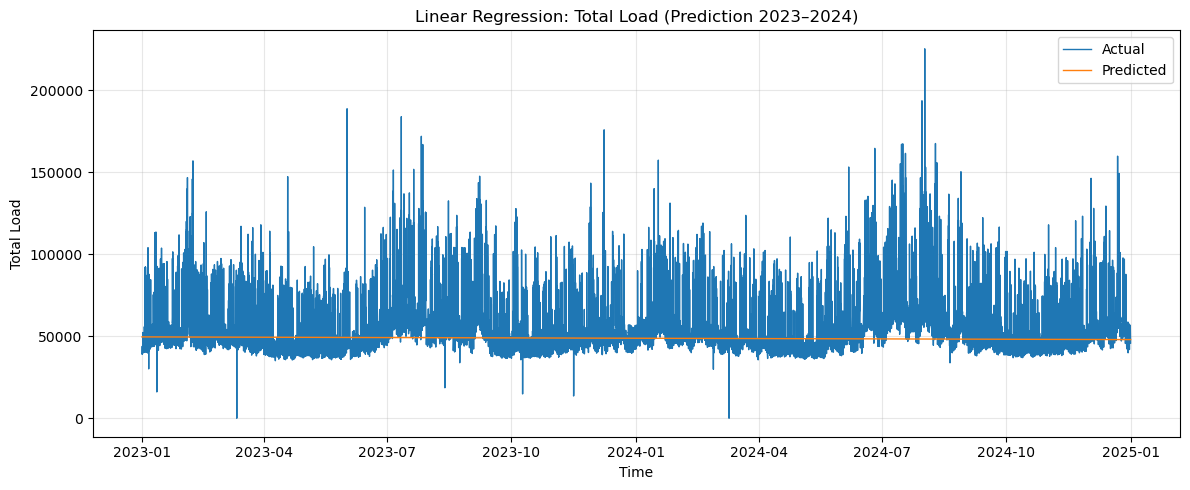

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# Hard-coded year windows
train_year_start = 2001
train_year_end = 2023
pred_start_target = pd.Timestamp('2023-01-01 00:00:00')
pred_end_target   = pd.Timestamp('2024-12-31 23:59:59')

# Train window mask (inclusive)
train_mask = (quarter.index.year >= train_year_start) & (quarter.index.year <= train_year_end)

# Prediction window: clamp to available data
available_start_2023 = quarter.index[quarter.index.year == 2023].min()
available_end_2024 = quarter.index[quarter.index.year == 2024].max() if (quarter.index.year == 2024).any() else quarter.index.max()

if pd.isna(available_start_2023):
    raise RuntimeError("No data found for year 2023 in 'quarter'.")
pred_start = max(pred_start_target, available_start_2023)
pred_end   = min(pred_end_target, available_end_2024)

# Slices
quarter_train = quarter.loc[train_mask].copy()
quarter_pred  = quarter.loc[pred_start:pred_end].copy()

# Features: time as seconds since epoch (simple linear trend vs time)
X_train = (quarter_train.index.astype('int64') // 10**9).values.reshape(-1, 1)
y_train = quarter_train['total_load'].values

X_pred  = (quarter_pred.index.astype('int64') // 10**9).values.reshape(-1, 1)
y_true  = quarter_pred['total_load'].values

# Fit
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on 2023–2024 window
y_pred = model.predict(X_pred)

# Metrics on prediction window
mse = mean_squared_error(y_true, y_pred)
r2  = r2_score(y_true, y_pred)

print("TRAINED: 2001–2023 (inclusive)")
print(f"PREDICT: {pred_start} -> {pred_end}")
print(f"Samples — train: {len(X_train):,}, predict: {len(X_pred):,}")
print(f"Intercept: {float(model.intercept_):.6f}")
print(f"Coefficient (per second): {float(np.ravel(model.coef_)[0]):.12f}")
print(f"Prediction MSE: {mse:.2f}")
print(f"Prediction R^2: {r2:.4f}")

# Plot predictions vs actual for the prediction window
plt.figure(figsize=(12, 5))
plt.plot(quarter_pred.index, y_true, label='Actual', color='tab:blue', linewidth=1)
plt.plot(quarter_pred.index, y_pred, label='Predicted', color='tab:orange', linewidth=1)
plt.title('Linear Regression: Total Load (Prediction 2023–2024)')
plt.xlabel('Time')
plt.ylabel('Total Load')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Optional: store predictions for later use
lr_pred_2023_2024 = pd.DataFrame(
    {'actual': y_true, 'pred': y_pred},
    index=quarter_pred.index
)

# Linear regression: train on 2001–2023, predict 2023-01-01 through 2024-12-31
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Guard + normalization
if 'quarter' not in globals():
    raise RuntimeError("quarter is not defined. Run the earlier aggregation cell to create it.")
if not isinstance(quarter.index, pd.DatetimeIndex):
    quarter.index = pd.to_datetime(quarter.index, errors='coerce')
quarter = quarter.sort_index()
if 'total_load' not in quarter.columns:
    raise RuntimeError("quarter must contain a 'total_load' column.")




Prediction window summary
  Range: 2023-01-01 00:00:00 -> 2024-12-31 23:45:00  (n=70,176)
  Actual:
    mean=52002.218, std=11464.106, min=0.000, max=225136.700
  Pred:
    mean=48757.355, std=473.322, min=47937.556, max=49577.154
  Errors:
    MAE=7818.404, MSE=142767659.736, RMSE=11948.542, MAPE=13.763%
    Bias (mean residual)=-3244.863
  Fit:
    R^2=-0.0863, Pearson r=-0.0544, Spearman ρ=-0.0575

Worst 5 days by RMSE:


,RMSE
Time Stamp,
2024-08-01,39134.746543
2024-07-15,35703.047718
2024-08-02,34058.472923
2024-07-16,33991.712030
2024-07-30,33745.447554



Monthly RMSE (head):


,RMSE
Time Stamp,
2023-01,8515.877324
2023-02,11582.746461
2023-03,8676.233555
2023-04,9150.936935
2023-05,8818.421749



Daily MAPE (head):


,MAPE_%
Time Stamp,
2023-01-01,13.026688
2023-01-02,9.789081
2023-01-03,12.735943
2023-01-04,10.577364
2023-01-05,11.504129


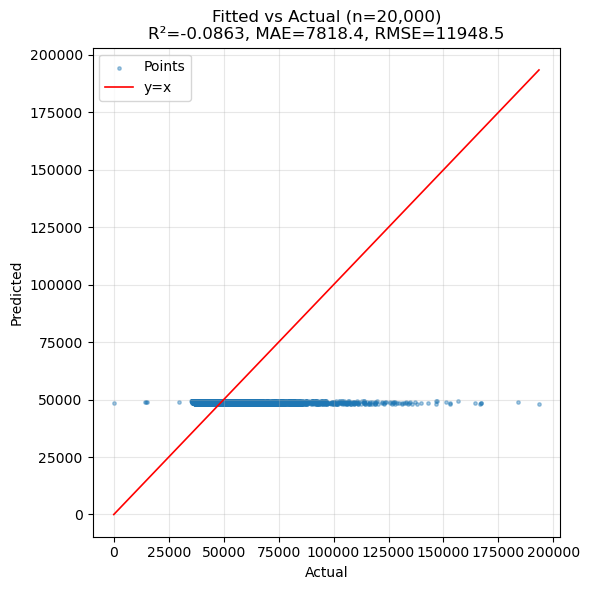

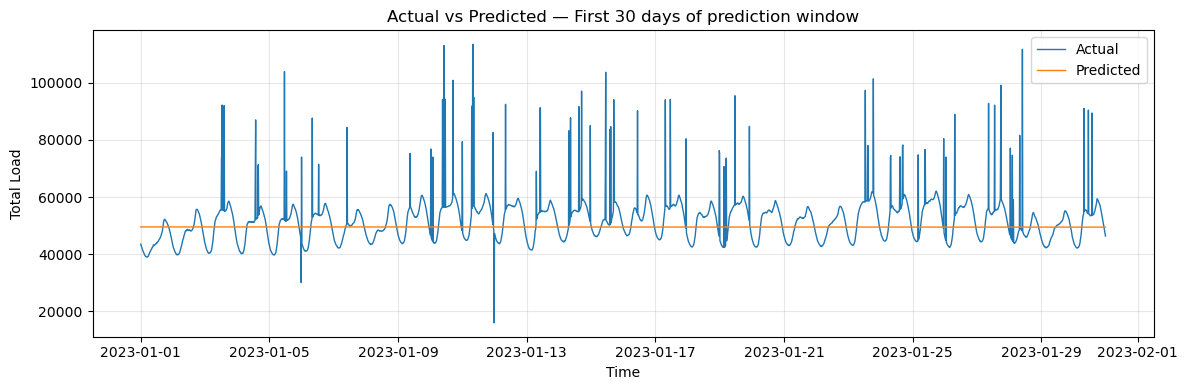

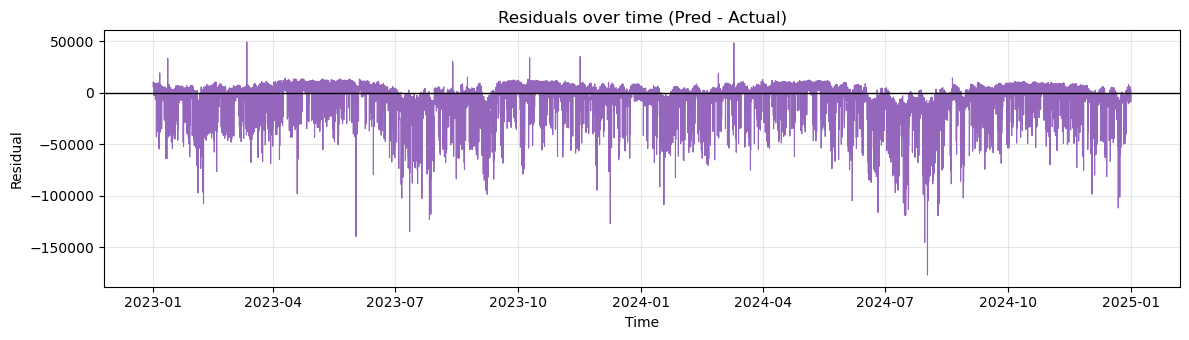

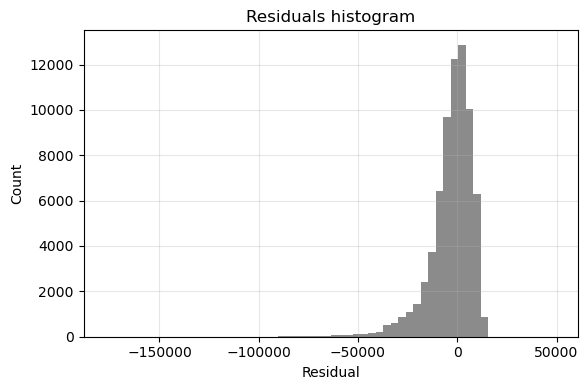

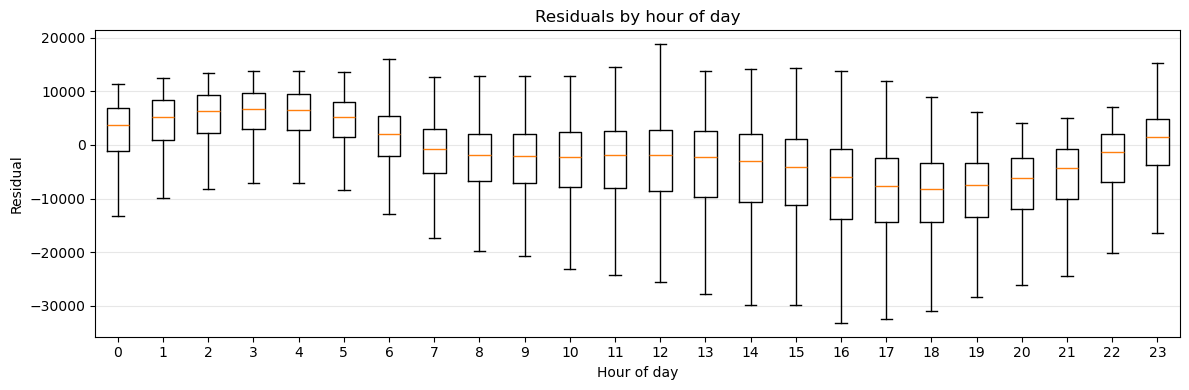


Prediction summary dict available as 'prediction_summary'.


In [75]:
# New cell — summary statistics and diagnostics (fitted vs actual)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Try to assemble predictions/actuals from existing variables
if 'lr_pred_2023_2024' in globals():
    df_pred = lr_pred_2023_2024.copy()
    if not isinstance(df_pred.index, pd.DatetimeIndex):
        df_pred.index = pd.to_datetime(df_pred.index, errors='coerce')
elif all(v in globals() for v in ['quarter_pred', 'y_true', 'y_pred']):
    df_pred = pd.DataFrame(
        {'actual': np.asarray(y_true).ravel(), 'pred': np.asarray(y_pred).ravel()},
        index=quarter_pred.index
    )
    if not isinstance(df_pred.index, pd.DatetimeIndex):
        df_pred.index = pd.to_datetime(df_pred.index, errors='coerce')
else:
    raise RuntimeError("No predictions found. Run the previous regression cell to create 'lr_pred_2023_2024' or 'quarter_pred/y_true/y_pred'.")

# Drop any NA rows for clean metrics/plots
df_pred = df_pred.dropna(subset=['actual', 'pred']).sort_index()
if df_pred.empty:
    raise RuntimeError("No valid rows after dropping NaNs in 'actual'/'pred'.")

# Basic residuals
df_pred['resid'] = df_pred['pred'] - df_pred['actual']

# Summary statistics
n = len(df_pred)
start_ts = df_pred.index.min()
end_ts = df_pred.index.max()
y_mean = df_pred['actual'].mean()
y_std  = df_pred['actual'].std()
y_min  = df_pred['actual'].min()
y_max  = df_pred['actual'].max()
p_mean = df_pred['pred'].mean()
p_std  = df_pred['pred'].std()
p_min  = df_pred['pred'].min()
p_max  = df_pred['pred'].max()

mae = np.mean(np.abs(df_pred['resid']))
mse = np.mean(df_pred['resid']**2)
rmse = np.sqrt(mse)
# Avoid division by zero in MAPE
mask_nonzero = df_pred['actual'] != 0
mape = (np.abs((df_pred.loc[mask_nonzero, 'actual'] - df_pred.loc[mask_nonzero, 'pred']) / df_pred.loc[mask_nonzero, 'actual']).mean() * 100.0) if mask_nonzero.any() else np.nan
bias = df_pred['resid'].mean()

# R^2 and correlations
# R^2 over the full prediction window:
ss_res = np.sum(df_pred['resid']**2)
ss_tot = np.sum((df_pred['actual'] - y_mean)**2)
r2 = 1 - ss_res/ss_tot if ss_tot != 0 else np.nan
pearson = np.corrcoef(df_pred['actual'], df_pred['pred'])[0,1] if n > 2 else np.nan
spearman = df_pred['actual'].corr(df_pred['pred'], method='spearman') if n > 2 else np.nan

# Print summary
print("Prediction window summary")
print(f"  Range: {start_ts} -> {end_ts}  (n={n:,})")
print("  Actual:")
print(f"    mean={y_mean:.3f}, std={y_std:.3f}, min={y_min:.3f}, max={y_max:.3f}")
print("  Pred:")
print(f"    mean={p_mean:.3f}, std={p_std:.3f}, min={p_min:.3f}, max={p_max:.3f}")
print("  Errors:")
print(f"    MAE={mae:.3f}, MSE={mse:.3f}, RMSE={rmse:.3f}, MAPE={mape:.3f}%")
print(f"    Bias (mean residual)={bias:.3f}")
print("  Fit:")
print(f"    R^2={r2:.4f}, Pearson r={pearson:.4f}, Spearman ρ={spearman:.4f}")

# Daily and monthly aggregates for diagnostics
daily_rmse = df_pred.groupby(df_pred.index.normalize())['resid'].apply(lambda r: np.sqrt(np.mean(r**2)))
monthly_rmse = df_pred.groupby(df_pred.index.to_period('M'))['resid'].apply(lambda r: np.sqrt(np.mean(r**2)))
daily_mape = df_pred.groupby(df_pred.index.normalize()).apply(
    lambda g: (np.abs((g.loc[g['actual']!=0, 'actual'] - g.loc[g['actual']!=0, 'pred']) / g.loc[g['actual']!=0, 'actual']).mean() * 100.0)
    if (g['actual']!=0).any() else np.nan
)

print("\nWorst 5 days by RMSE:")
display(daily_rmse.sort_values(ascending=False).head(5).to_frame('RMSE'))
print("\nMonthly RMSE (head):")
display(monthly_rmse.head().to_frame('RMSE'))
print("\nDaily MAPE (head):")
display(daily_mape.head().to_frame('MAPE_%'))

# ========== Plots ==========

# 1) Fitted vs Actual (scatter) with 45-degree line
plt.figure(figsize=(6,6))
# Subsample if very large for readability
max_points = 20000
if len(df_pred) > max_points:
    sampled = df_pred.sample(max_points, random_state=42)
else:
    sampled = df_pred
plt.scatter(sampled['actual'], sampled['pred'], s=6, alpha=0.4, color='tab:blue', label='Points')
lims_min = float(min(sampled['actual'].min(), sampled['pred'].min()))
lims_max = float(max(sampled['actual'].max(), sampled['pred'].max()))
plt.plot([lims_min, lims_max], [lims_min, lims_max], color='red', linewidth=1.2, label='y=x')
plt.title(f'Fitted vs Actual (n={len(sampled):,})\nR²={r2:.4f}, MAE={mae:.1f}, RMSE={rmse:.1f}')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 2) Time series overlay (first ~30 days of prediction window for visibility)
start_view = df_pred.index.min()
end_view = start_view + pd.Timedelta(days=30)
view = df_pred.loc[start_view:end_view]

plt.figure(figsize=(12,4))
plt.plot(view.index, view['actual'], label='Actual', color='tab:blue', linewidth=1)
plt.plot(view.index, view['pred'],   label='Predicted', color='tab:orange', linewidth=1)
plt.title('Actual vs Predicted — First 30 days of prediction window')
plt.xlabel('Time')
plt.ylabel('Total Load')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 3) Residuals over time
plt.figure(figsize=(12,3.5))
plt.plot(df_pred.index, df_pred['resid'], color='tab:purple', linewidth=0.8)
plt.axhline(0, color='black', linewidth=1)
plt.title('Residuals over time (Pred - Actual)')
plt.xlabel('Time')
plt.ylabel('Residual')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4) Residuals distribution
plt.figure(figsize=(6,4))
plt.hist(df_pred['resid'], bins=60, color='tab:gray', alpha=0.9)
plt.title('Residuals histogram')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5) Residuals by hour-of-day (boxplot)
if isinstance(df_pred.index, pd.DatetimeIndex):
    hour_of_day = df_pred.index.hour
    # To keep simple and avoid seaborn, use matplotlib boxplot grouped by hour
    data_by_hour = [df_pred.loc[hour_of_day == h, 'resid'].values for h in range(24)]
    plt.figure(figsize=(12,4))
    plt.boxplot(data_by_hour, positions=range(24), showfliers=False)
    plt.title('Residuals by hour of day')
    plt.xlabel('Hour of day')
    plt.ylabel('Residual')
    plt.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

# Expose key outputs for reuse
prediction_summary = {
    'n': n, 'start': start_ts, 'end': end_ts,
    'y_mean': y_mean, 'y_std': y_std, 'y_min': y_min, 'y_max': y_max,
    'p_mean': p_mean, 'p_std': p_std, 'p_min': p_min, 'p_max': p_max,
    'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE_%': mape, 'Bias': bias,
    'R2': r2, 'Pearson_r': pearson, 'Spearman_rho': spearman
}
print("\nPrediction summary dict available as 'prediction_summary'.")